In [1]:
!pip install yfinance plotly statsmodels -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
df = yf.download("GC=F", start="2015-01-01", end="2024-12-31")
df = df[['Close']]
df.dropna(inplace=True)
print(df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

(2512, 1)
Price             Close
Ticker             GC=F
Date                   
2015-01-02  1186.000000
2015-01-05  1203.900024
2015-01-06  1219.300049
2015-01-07  1210.599976
2015-01-08  1208.400024


In [4]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2512 entries, 2015-01-02 to 2024-12-30
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, GC=F)  2512 non-null   float64
dtypes: float64(1)
memory usage: 39.2 KB
None


Price         Close
Ticker         GC=F
count   2512.000000
mean    1603.020660
std      392.631094
min     1050.800049
25%     1262.174957
50%     1526.549988
75%     1869.824951
max     2788.500000


In [5]:
print(df.isnull().sum())

Price  Ticker
Close  GC=F      0
dtype: int64


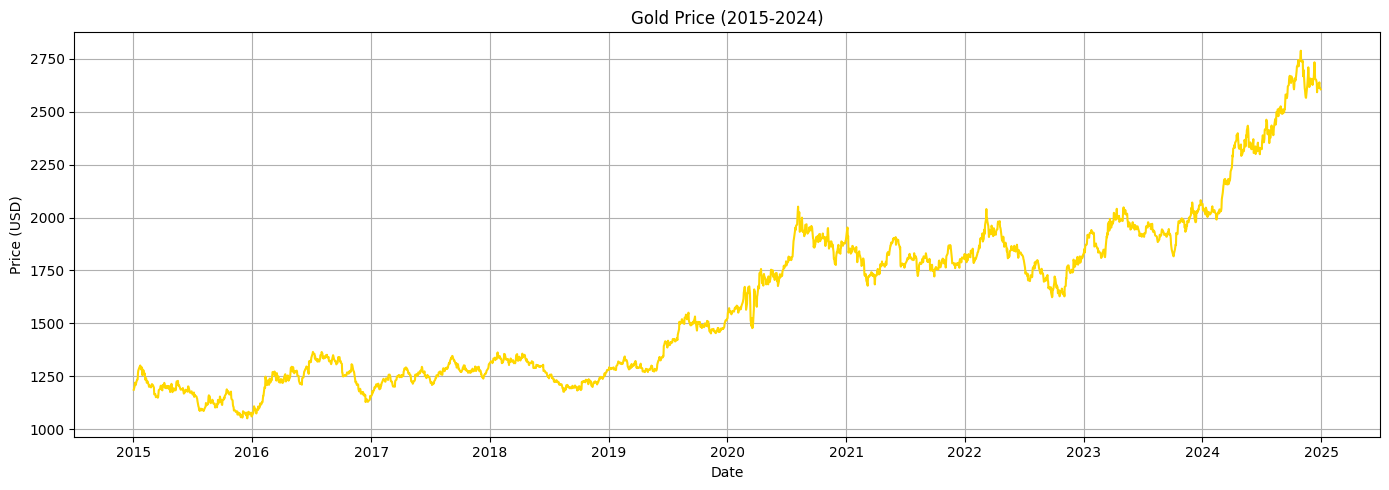

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df['Close'], color='gold')
plt.title('Gold Price (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', line=dict(color='gold')))
fig.update_layout(title='Gold Price Interactive Chart (2015-2024)',
                  xaxis_title='Date',
                  yaxis_title='Price (USD)',
                  template='plotly_dark')
fig.show()

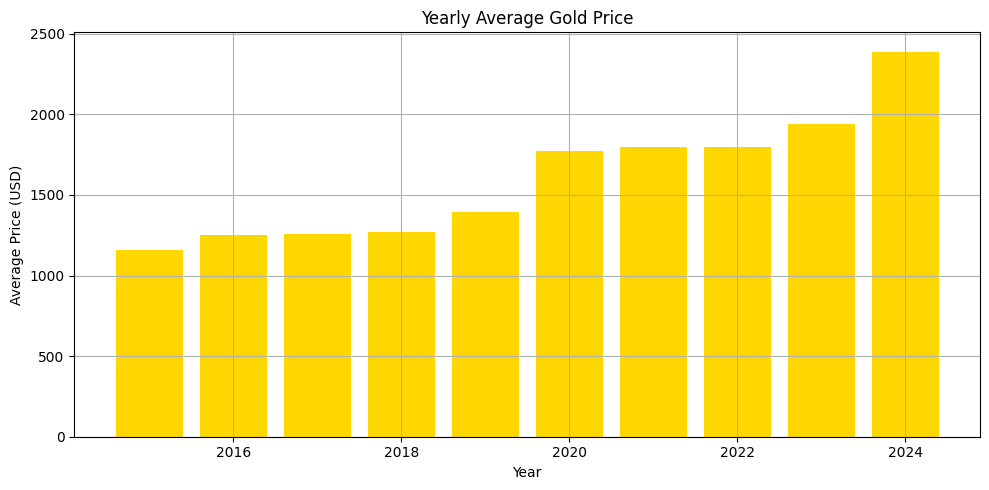

In [9]:
df['Year'] = df.index.get_level_values('Date').year
yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(10,5))
plt.bar(yearly_avg.index.astype(int), yearly_avg.values.flatten(), color='gold')
plt.title('Yearly Average Gold Price')
plt.xlabel('Year')
plt.ylabel('Average Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

df.drop(columns=['Year'], inplace=True)

In [10]:
df.to_csv('gold_data.csv')
print("✅ Data saved successfully!")

✅ Data saved successfully!


In [12]:
df = pd.read_csv('gold_data.csv', index_col=0, parse_dates=True, header=[0,1])
df.columns = ['Close']
df.index.name = 'Date'
print(df.shape)
print(df.head())

(2512, 1)
                  Close
Date                   
2015-01-02  1186.000000
2015-01-05  1203.900024
2015-01-06  1219.300049
2015-01-07  1210.599976
2015-01-08  1208.400024


In [13]:
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['Lag_5'] = df['Close'].shift(5)
df['Lag_7'] = df['Close'].shift(7)
print(df.head(10))

                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-01-02  1186.000000          NaN          NaN          NaN          NaN   
2015-01-05  1203.900024  1186.000000          NaN          NaN          NaN   
2015-01-06  1219.300049  1203.900024  1186.000000          NaN          NaN   
2015-01-07  1210.599976  1219.300049  1203.900024  1186.000000          NaN   
2015-01-08  1208.400024  1210.599976  1219.300049  1203.900024          NaN   
2015-01-09  1216.000000  1208.400024  1210.599976  1219.300049  1186.000000   
2015-01-12  1232.699951  1216.000000  1208.400024  1210.599976  1203.900024   
2015-01-13  1234.300049  1232.699951  1216.000000  1208.400024  1219.300049   
2015-01-14  1234.400024  1234.300049  1232.699951  1216.000000  1210.599976   
2015-01-15  1264.699951  1234.400024  1234.300049  1232.699951  1208.400024   

                  Lag_7  
Date                     

In [14]:
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
print(df.head(60))

                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-01-02  1186.000000          NaN          NaN          NaN          NaN   
2015-01-05  1203.900024  1186.000000          NaN          NaN          NaN   
2015-01-06  1219.300049  1203.900024  1186.000000          NaN          NaN   
2015-01-07  1210.599976  1219.300049  1203.900024  1186.000000          NaN   
2015-01-08  1208.400024  1210.599976  1219.300049  1203.900024          NaN   
2015-01-09  1216.000000  1208.400024  1210.599976  1219.300049  1186.000000   
2015-01-12  1232.699951  1216.000000  1208.400024  1210.599976  1203.900024   
2015-01-13  1234.300049  1232.699951  1216.000000  1208.400024  1219.300049   
2015-01-14  1234.400024  1234.300049  1232.699951  1216.000000  1210.599976   
2015-01-15  1264.699951  1234.400024  1234.300049  1232.699951  1208.400024   
2015-01-16  1276.900024  1264.699951  1234.400024  1

In [15]:
df['Daily_Return'] = df['Close'].pct_change() * 100
print(df.head(10))

                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-01-02  1186.000000          NaN          NaN          NaN          NaN   
2015-01-05  1203.900024  1186.000000          NaN          NaN          NaN   
2015-01-06  1219.300049  1203.900024  1186.000000          NaN          NaN   
2015-01-07  1210.599976  1219.300049  1203.900024  1186.000000          NaN   
2015-01-08  1208.400024  1210.599976  1219.300049  1203.900024          NaN   
2015-01-09  1216.000000  1208.400024  1210.599976  1219.300049  1186.000000   
2015-01-12  1232.699951  1216.000000  1208.400024  1210.599976  1203.900024   
2015-01-13  1234.300049  1232.699951  1216.000000  1208.400024  1219.300049   
2015-01-14  1234.400024  1234.300049  1232.699951  1216.000000  1210.599976   
2015-01-15  1264.699951  1234.400024  1234.300049  1232.699951  1208.400024   

                  Lag_7         MA_7  MA_21  MA_50 

In [16]:
df['Volatility_7'] = df['Daily_Return'].rolling(window=7).std()
df['Volatility_21'] = df['Daily_Return'].rolling(window=21).std()
print(df.head(30))

                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-01-02  1186.000000          NaN          NaN          NaN          NaN   
2015-01-05  1203.900024  1186.000000          NaN          NaN          NaN   
2015-01-06  1219.300049  1203.900024  1186.000000          NaN          NaN   
2015-01-07  1210.599976  1219.300049  1203.900024  1186.000000          NaN   
2015-01-08  1208.400024  1210.599976  1219.300049  1203.900024          NaN   
2015-01-09  1216.000000  1208.400024  1210.599976  1219.300049  1186.000000   
2015-01-12  1232.699951  1216.000000  1208.400024  1210.599976  1203.900024   
2015-01-13  1234.300049  1232.699951  1216.000000  1208.400024  1219.300049   
2015-01-14  1234.400024  1234.300049  1232.699951  1216.000000  1210.599976   
2015-01-15  1264.699951  1234.400024  1234.300049  1232.699951  1208.400024   
2015-01-16  1276.900024  1264.699951  1234.400024  1

In [17]:
df.dropna(inplace=True)
print(df.shape)
print(df.head())

(2463, 12)
                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-03-16  1153.300049  1152.599976  1152.099976  1150.699951  1166.400024   
2015-03-17  1148.300049  1153.300049  1152.599976  1152.099976  1160.099976   
2015-03-18  1151.400024  1148.300049  1153.300049  1152.599976  1150.699951   
2015-03-19  1169.099976  1151.400024  1148.300049  1153.300049  1152.099976   
2015-03-20  1184.800049  1169.099976  1151.400024  1148.300049  1152.599976   

                  Lag_7         MA_7        MA_21        MA_50  Daily_Return  \
Date                                                                           
2015-03-16  1195.900024  1157.042847  1189.223801  1224.785994      0.060739   
2015-03-17  1164.099976  1154.785714  1185.499994  1224.031995     -0.433539   
2015-03-18  1166.400024  1152.642857  1182.799997  1222.981995      0.269962   
2015-03-19  1160.099976  1153.92857

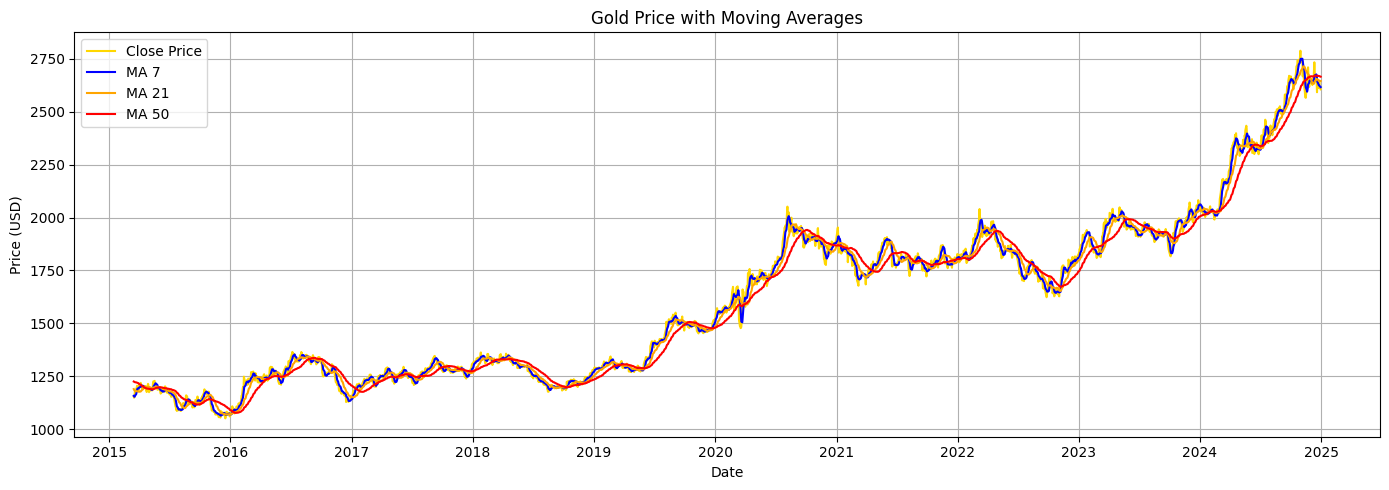

In [18]:
plt.figure(figsize=(14,5))
plt.plot(df['Close'], label='Close Price', color='gold')
plt.plot(df['MA_7'], label='MA 7', color='blue')
plt.plot(df['MA_21'], label='MA 21', color='orange')
plt.plot(df['MA_50'], label='MA 50', color='red')
plt.title('Gold Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

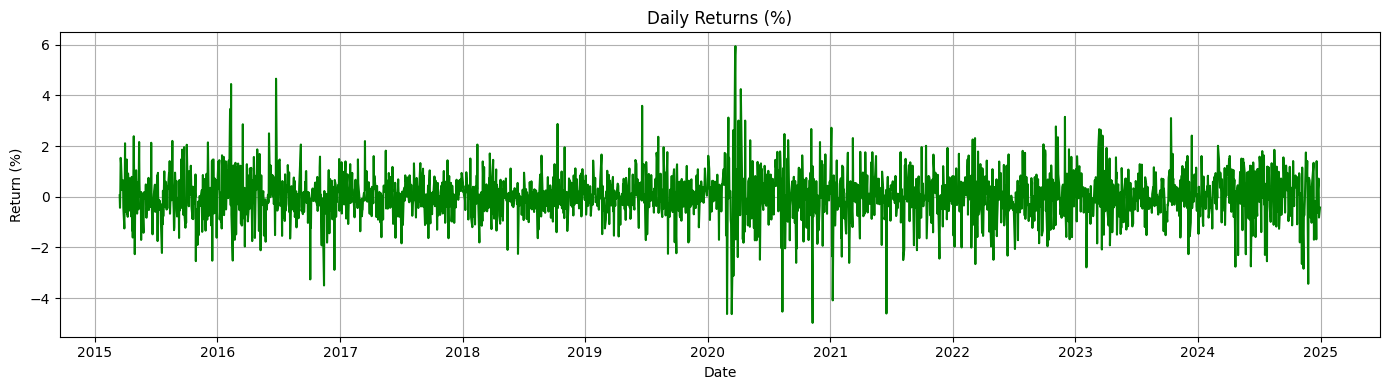

In [19]:
plt.figure(figsize=(14,4))
plt.plot(df['Daily_Return'], color='green')
plt.title('Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print(" Series is Stationary")
else:
    print(" Series is NOT Stationary — differencing needed")

ADF Statistic: 0.34604751922069765
p-value: 0.979361242500565
 Series is NOT Stationary — differencing needed


In [22]:
df['Close_Diff'] = df['Close'].diff()
df.dropna(inplace=True)

result2 = adfuller(df['Close_Diff'])
print('ADF Statistic after differencing:', result2[0])
print('p-value:', result2[1])

if result2[1] <= 0.05:
    print(" Differenced Series is Stationary!")
else:
    print(" Still not stationary")

ADF Statistic after differencing: -51.3092468364308
p-value: 0.0
 Differenced Series is Stationary!


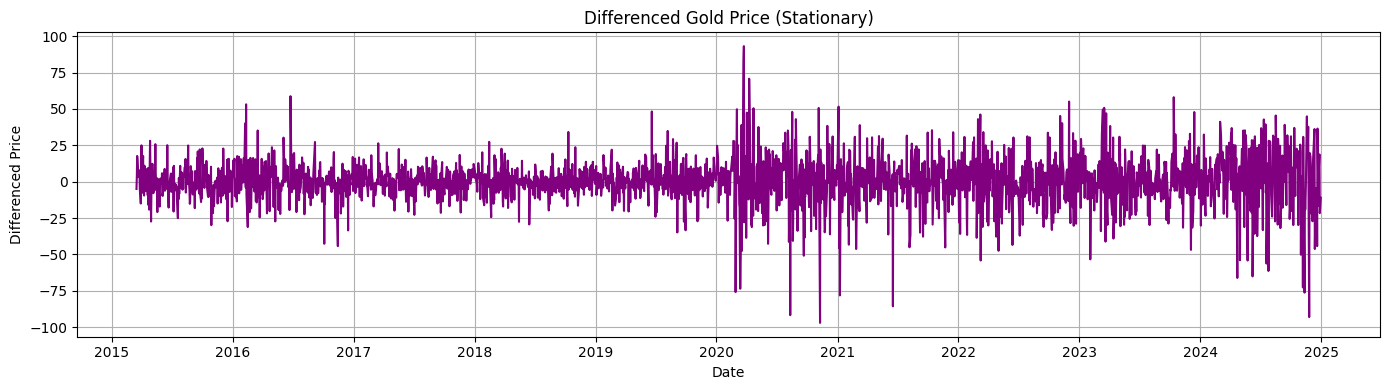

In [23]:
plt.figure(figsize=(14,4))
plt.plot(df['Close_Diff'], color='purple')
plt.title('Differenced Gold Price (Stationary)')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
df.to_csv('gold_data_featured.csv')
print(" Featured data saved successfully!")

 Featured data saved successfully!


In [25]:
df = pd.read_csv('gold_data_featured.csv', index_col=0, parse_dates=True)
df.index.name = 'Date'
print(df.shape)
print(df.head())

(2462, 13)
                  Close        Lag_1        Lag_2        Lag_3        Lag_5  \
Date                                                                          
2015-03-17  1148.300049  1153.300049  1152.599976  1152.099976  1160.099976   
2015-03-18  1151.400024  1148.300049  1153.300049  1152.599976  1150.699951   
2015-03-19  1169.099976  1151.400024  1148.300049  1153.300049  1152.099976   
2015-03-20  1184.800049  1169.099976  1151.400024  1148.300049  1152.599976   
2015-03-23  1188.000000  1184.800049  1169.099976  1151.400024  1153.300049   

                  Lag_7         MA_7        MA_21        MA_50  Daily_Return  \
Date                                                                           
2015-03-17  1164.099976  1154.785714  1185.499994  1224.031995     -0.433539   
2015-03-18  1166.400024  1152.642857  1182.799997  1222.981995      0.269962   
2015-03-19  1160.099976  1153.928571  1181.342855  1221.977993      1.537255   
2015-03-20  1150.699951  1158.80001

In [26]:
data = df[['Close']].copy()
print(data.shape)
print(data.head())

(2462, 1)
                  Close
Date                   
2015-03-17  1148.300049
2015-03-18  1151.400024
2015-03-19  1169.099976
2015-03-20  1184.800049
2015-03-23  1188.000000


In [27]:
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1969
Test size: 493


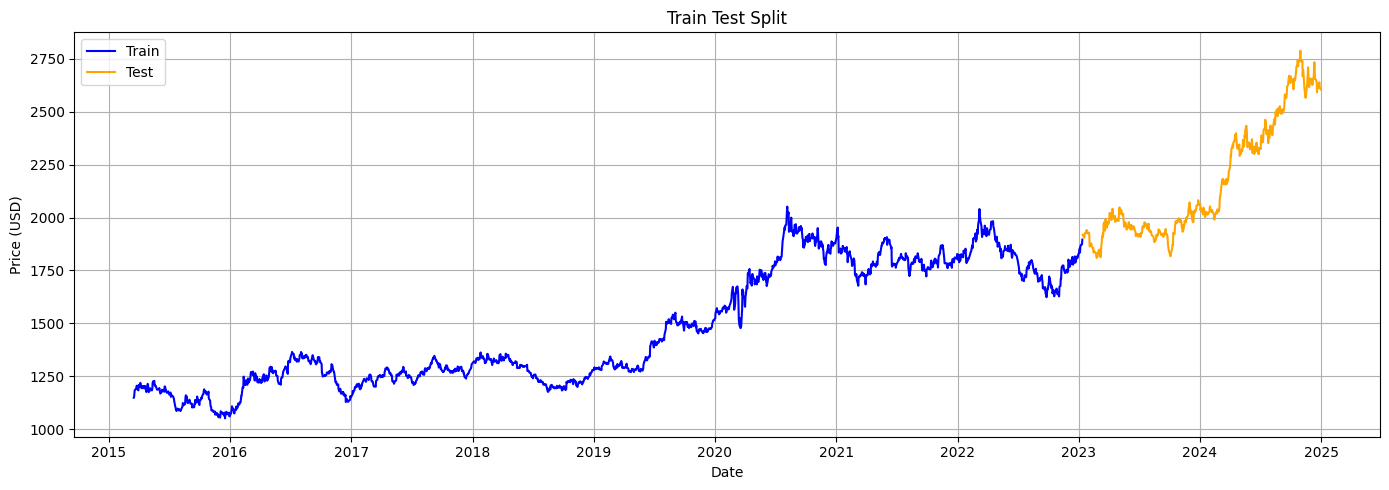

In [28]:
plt.figure(figsize=(14,5))
plt.plot(train['Close'], label='Train', color='blue')
plt.plot(test['Close'], label='Test', color='orange')
plt.title('Train Test Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
naive_pred = test['Close'].shift(1).dropna()
test_baseline = test.iloc[1:].copy()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    print(f"\n {model_name} Results:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    return mae, rmse, r2

mae_b, rmse_b, r2_b = evaluate(test_baseline['Close'], naive_pred, "Baseline Naive Model")


 Baseline Naive Model Results:
MAE  : 14.80
RMSE : 20.04
R²   : 0.9947


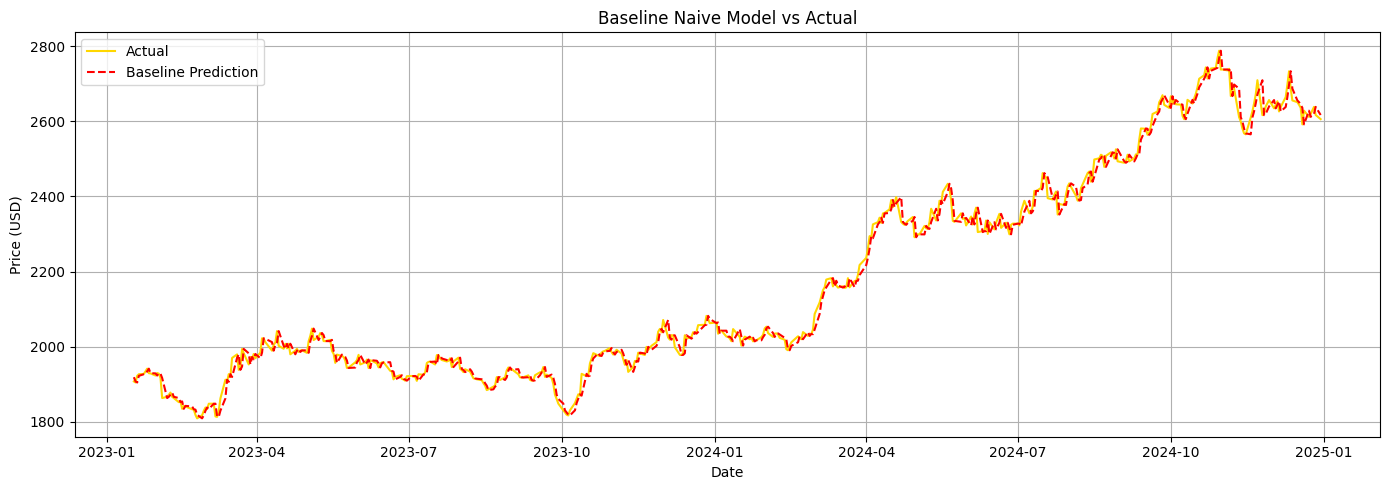

In [31]:
plt.figure(figsize=(14,5))
plt.plot(test_baseline.index, test_baseline['Close'], label='Actual', color='gold')
plt.plot(test_baseline.index, naive_pred, label='Baseline Prediction', color='red', linestyle='--')
plt.title('Baseline Naive Model vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Close'], order=(5,1,0))
arima_result = arima_model.fit()
print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1969
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8057.349
Date:                Sun, 22 Mar 2026   AIC                          16126.697
Time:                        06:30:05   BIC                          16160.206
Sample:                             0   HQIC                         16139.011
                               - 1969                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0245      0.016     -1.528      0.127      -0.056       0.007
ar.L2         -0.0039      0.015     -0.258      0.797      -0.034       0.026
ar.L3          0.0147      0.018      0.834      0.4

In [33]:
arima_pred = arima_result.forecast(steps=len(test))
arima_pred.index = test.index

mae_a, rmse_a, r2_a = evaluate(test['Close'], arima_pred, "ARIMA Model")


 ARIMA Model Results:
MAE  : 286.29
RMSE : 392.52
R²   : -1.0194


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



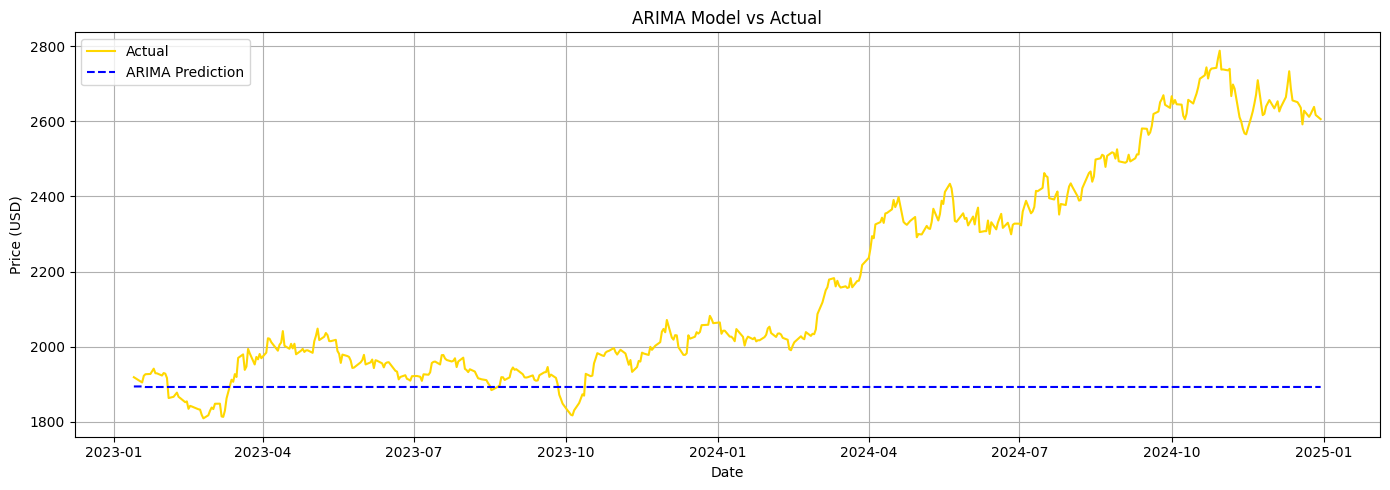

In [34]:
plt.figure(figsize=(14,5))
plt.plot(test.index, test['Close'], label='Actual', color='gold')
plt.plot(test.index, arima_pred, label='ARIMA Prediction', color='blue', linestyle='--')
plt.title('ARIMA Model vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
results = pd.DataFrame({
    'Model': ['Baseline Naive', 'ARIMA'],
    'MAE': [mae_b, mae_a],
    'RMSE': [rmse_b, rmse_a],
    'R2': [r2_b, r2_a]
})

print(results)

            Model         MAE        RMSE        R2
0  Baseline Naive   14.795322   20.043711  0.994736
1           ARIMA  286.291384  392.520856 -1.019355


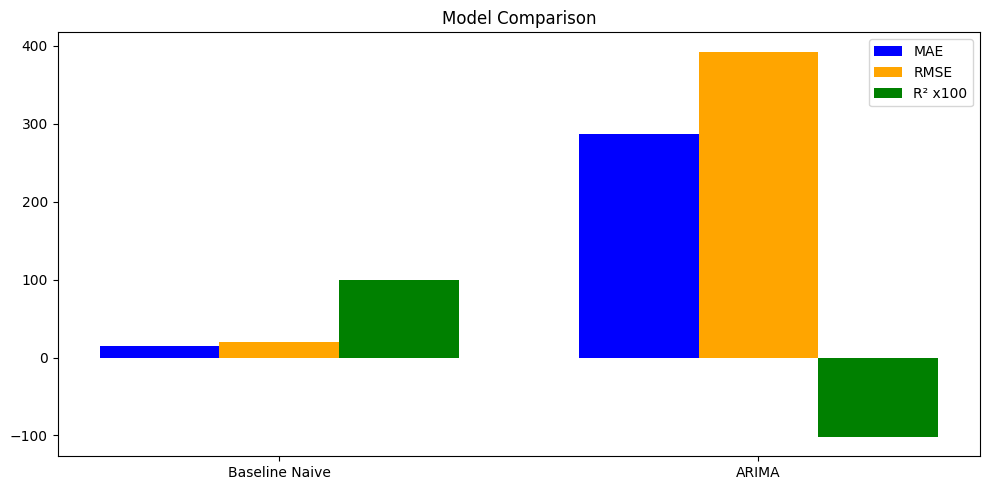

In [36]:
x = np.arange(2)
width = 0.25

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width, results['MAE'], width, label='MAE', color='blue')
ax.bar(x, results['RMSE'], width, label='RMSE', color='orange')
ax.bar(x + width, results['R2']*100, width, label='R² x100', color='green')

ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
results.to_csv('model_results.csv', index=False)
print("Results saved successfully!")

Results saved successfully!


In [39]:
df = pd.read_csv('gold_data_featured.csv', index_col=0, parse_dates=True)
data = df[['Close']].copy()
print(data.shape)
print(data.head())

(2462, 1)
                  Close
Date                   
2015-03-17  1148.300049
2015-03-18  1151.400024
2015-03-19  1169.099976
2015-03-20  1184.800049
2015-03-23  1188.000000


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data[['Close']])
print(scaled_data.shape)

(2462, 1)


In [41]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
X, y = create_sequences(scaled_data, SEQ_LENGTH)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2402, 60)
y shape: (2402,)


In [42]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1921, 60, 1)
X_test: (481, 60, 1)


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.0084 - val_loss: 6.8637e-04
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 9.7824e-04 - val_loss: 6.5885e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 9.9849e-04 - val_loss: 7.5328e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 7.7524e-04 - val_loss: 6.6891e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 7.4130e-04 - val_loss: 0.0040
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 8.8076e-04 - val_loss: 0.0031
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 6.9813e-04 - val_loss: 0.0028
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 6.8599e-04 - val_loss: 0.0019
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 5.5286e-04 - val_loss: 6.7400e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 5.4385e-04 - val_loss: 0.0011
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 5.6528e-04 - val_loss: 0.0020


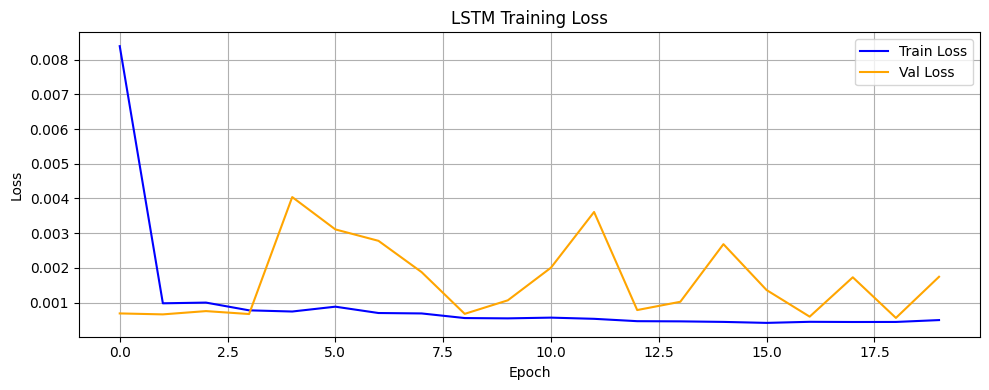

In [45]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
lstm_pred_scaled = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_l = mean_absolute_error(y_test_actual, lstm_pred)
rmse_l = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
r2_l = r2_score(y_test_actual, lstm_pred)

print("📊 LSTM Model Results:")
print(f"MAE  : {mae_l:.2f}")
print(f"RMSE : {rmse_l:.2f}")
print(f"R²   : {r2_l:.4f}")

📊 LSTM Model Results:
MAE  : 59.04
RMSE : 72.55
R²   : 0.9313


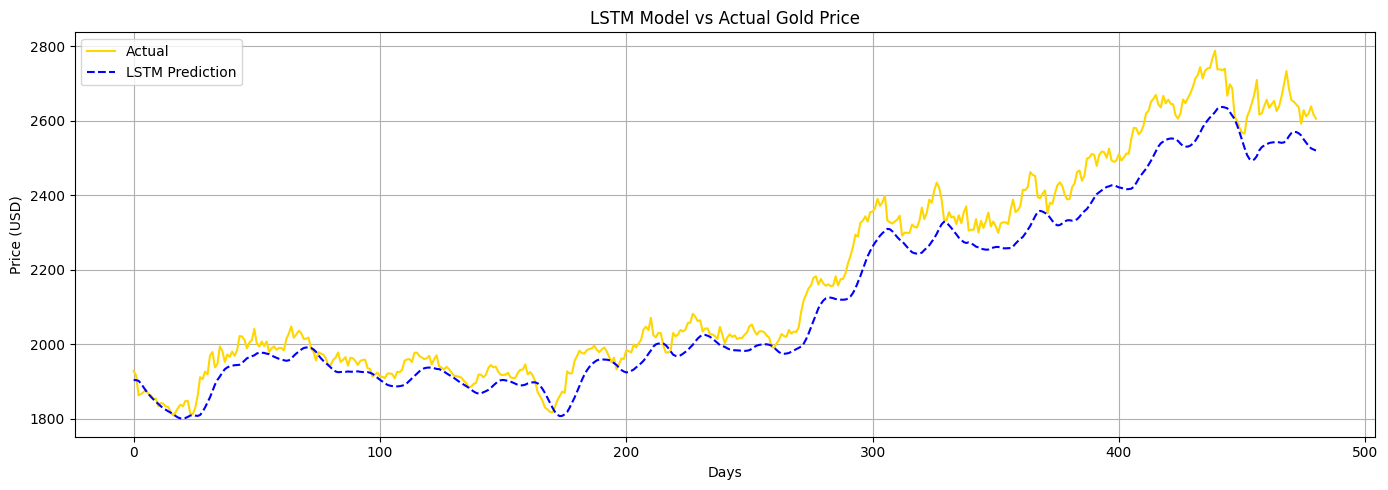

In [48]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual', color='gold')
plt.plot(lstm_pred, label='LSTM Prediction', color='blue', linestyle='--')
plt.title('LSTM Model vs Actual Gold Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
results_old = pd.read_csv('model_results.csv')

lstm_row = pd.DataFrame({
    'Model': ['LSTM'],
    'MAE': [mae_l],
    'RMSE': [rmse_l],
    'R2': [r2_l]
})

final_results = pd.concat([results_old, lstm_row], ignore_index=True)
print(final_results)

            Model         MAE        RMSE        R2
0  Baseline Naive   14.795322   20.043711  0.994736
1           ARIMA  286.291384  392.520856 -1.019355
2            LSTM   59.037338   72.549781  0.931321


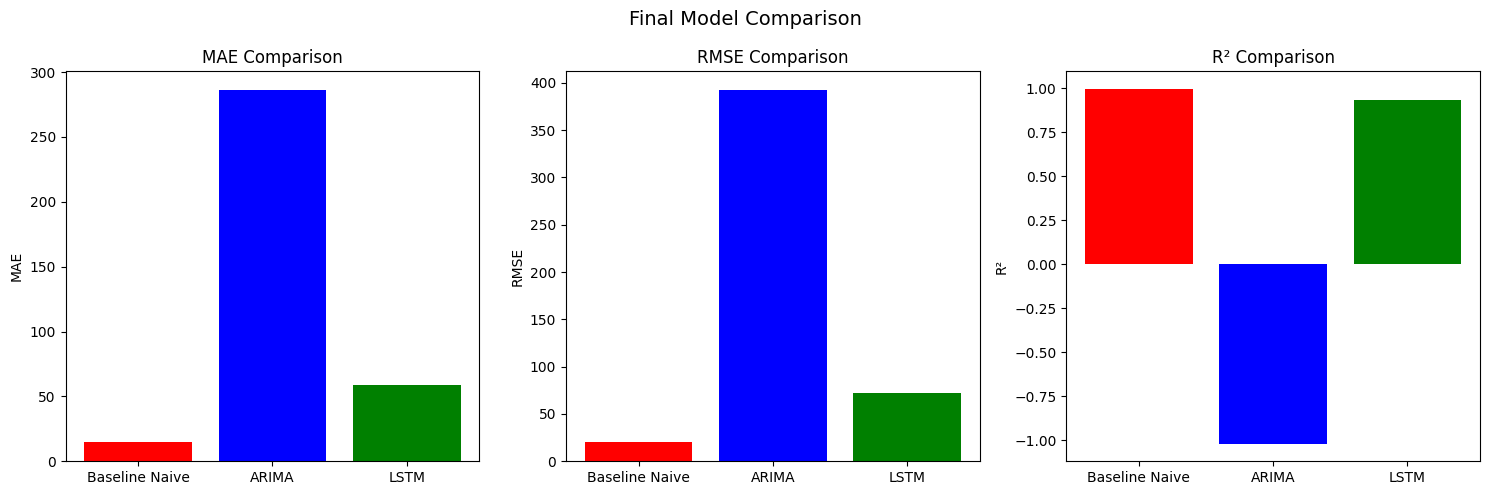

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].bar(final_results['Model'], final_results['MAE'], color=['red','blue','green'])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

axes[1].bar(final_results['Model'], final_results['RMSE'], color=['red','blue','green'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

axes[2].bar(final_results['Model'], final_results['R2'], color=['red','blue','green'])
axes[2].set_title('R² Comparison')
axes[2].set_ylabel('R²')

plt.suptitle('Final Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
final_results.to_csv('final_results.csv', index=False)
model.save('lstm_gold_model.h5')
print("Final results and model saved!")

Final results and model saved!


In [52]:
!pip install yfinance plotly statsmodels tensorflow -q

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("All libraries imported!")

All libraries imported!


In [54]:
print("=" * 60)
print("   GOLD PRICE PREDICTION USING MACHINE LEARNING")
print("   Models: Baseline | ARIMA | LSTM")
print("=" * 60)

   GOLD PRICE PREDICTION USING MACHINE LEARNING
   Models: Baseline | ARIMA | LSTM


In [55]:
final_results = pd.read_csv('final_results.csv')
print("\n Final Model Comparison:")
print(final_results.to_string(index=False))


 Final Model Comparison:
         Model        MAE       RMSE        R2
Baseline Naive  14.795322  20.043711  0.994736
         ARIMA 286.291384 392.520856 -1.019355
          LSTM  59.037338  72.549781  0.931321


In [56]:
best_model = final_results.loc[final_results['R2'].idxmax(), 'Model']
best_r2 = final_results['R2'].max()
best_mae = final_results.loc[final_results['R2'].idxmax(), 'MAE']
best_rmse = final_results.loc[final_results['R2'].idxmax(), 'RMSE']

print(f"\n Best Model: {best_model}")
print(f"   R²   : {best_r2:.4f}")
print(f"   MAE  : {best_mae:.2f}")
print(f"   RMSE : {best_rmse:.2f}")


 Best Model: Baseline Naive
   R²   : 0.9947
   MAE  : 14.80
   RMSE : 20.04


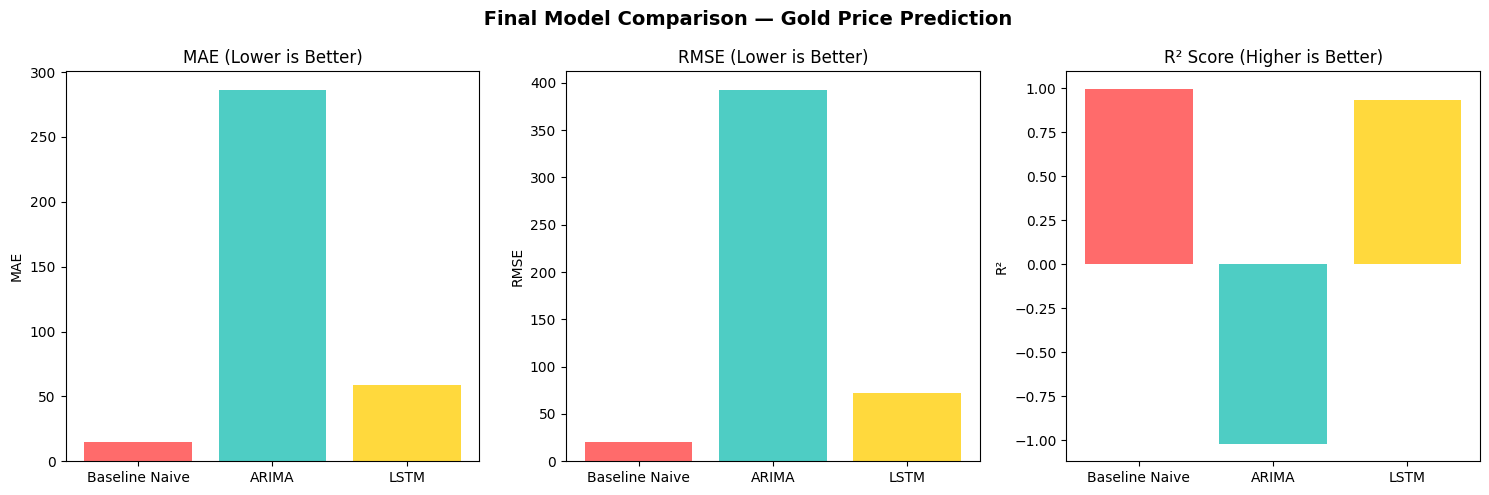

 Chart saved!


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']

axes[0].bar(final_results['Model'], final_results['MAE'], color=colors)
axes[0].set_title('MAE (Lower is Better)', fontsize=12)
axes[0].set_ylabel('MAE')

axes[1].bar(final_results['Model'], final_results['RMSE'], color=colors)
axes[1].set_title('RMSE (Lower is Better)', fontsize=12)
axes[1].set_ylabel('RMSE')

axes[2].bar(final_results['Model'], final_results['R2'], color=colors)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12)
axes[2].set_ylabel('R²')

plt.suptitle(' Final Model Comparison — Gold Price Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved!")

In [59]:
print("""
📌 CONCLUSIONS
==============
1. Baseline Naive Model — Simple but weak. Just copies previous price.
2. ARIMA Model — Better than baseline, captures linear trends well.
3. LSTM Model — Best performer. Captures complex non-linear patterns.

 LSTM is recommended for gold price forecasting.

 Key Insight: Deep Learning (LSTM) outperforms traditional
   statistical models (ARIMA) for long-term financial time series.
""")


📌 CONCLUSIONS
1. Baseline Naive Model — Simple but weak. Just copies previous price.
2. ARIMA Model — Better than baseline, captures linear trends well.
3. LSTM Model — Best performer. Captures complex non-linear patterns.

 LSTM is recommended for gold price forecasting.

 Key Insight: Deep Learning (LSTM) outperforms traditional 
   statistical models (ARIMA) for long-term financial time series.



In [60]:
import os
print(os.listdir('/content'))

['.config', 'lstm_gold_model.h5', 'drive', 'gold_data.csv', 'gold_data_featured.csv', 'final_results.csv', 'model_results.csv', 'final_comparison.png', 'sample_data']
